# Fine Tuning DeBERTa for Emotion Classification


In [ ]:
# Dependencies

!pip install datasets

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import Dataset
from collections import Counter
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.nn import CrossEntropyLoss
from transformers import AutoModelForSequenceClassification
from transformers import AutoTokenizer
from transformers import DataCollatorWithPadding
from transformers import EarlyStoppingCallback
from transformers import Trainer
from transformers import TrainingArguments

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.cuda.get_device_name(0))

NVIDIA A100-SXM4-40GB


## Load Data

In [3]:
df = pd.read_csv('/content/disgust_augmented_emotions.csv')

In [4]:
df.head()

,id,artist,seq,song,label_name,label
0,0,Elijah Blake,"No, no I ain't ever trapped out the bando But ...",Everyday,fear,0
1,1,Elijah Blake,"The drinks go down and smoke goes up, I feel m...",Live Till We Die,sadness,1
2,3,Elijah Blake,"Trippin' off that Grigio, mobbin', lights low ...",Pinot,surprise,2
3,7,Elis,Dieses ist lange her. Da ich deine schmalen Ha...,Abendlied,fear,0
4,8,Elis,A child is born Out of the womb of a mother Wh...,Child,sadness,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23476 entries, 0 to 23475
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          23476 non-null  int64 
 1   artist      23476 non-null  object
 2   seq         23476 non-null  object
 3   song        23476 non-null  object
 4   label_name  23476 non-null  object
 5   label       23476 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 1.1+ MB


In [6]:
df["label_name"].value_counts()

,count
label_name,
fear,8307
sadness,7399
anger,3341
joy,1743
disgust,1383
surprise,1303


## Tokenize

In [ ]:
model_name = 'microsoft/deberta-v3-base'
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [8]:
emotions = df["label_name"].unique()
emotions

array(['fear', 'sadness', 'surprise', 'anger', 'joy', 'disgust'],
      dtype=object)

In [9]:
label2id = {emotion:i for i, emotion in enumerate(emotions)}
id2label = {v:k for k, v in label2id.items()}
print(label2id)
print(id2label)

{'fear': 0, 'sadness': 1, 'surprise': 2, 'anger': 3, 'joy': 4, 'disgust': 5}
{0: 'fear', 1: 'sadness', 2: 'surprise', 3: 'anger', 4: 'joy', 5: 'disgust'}


In [10]:
df["label"] = df["label_name"].map(label2id)

In [11]:
def tokenize_function(examples):
    return tokenizer(examples["seq"], padding="max_length", truncation=True, max_length=512)

In [12]:
train, test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label_name'])
test, validation = train_test_split(test, test_size=1/2, random_state=42, stratify=test['label_name'])

In [ ]:
train_dataset = Dataset.from_pandas(train)
val_dataset = Dataset.from_pandas(validation)
test_dataset = Dataset.from_pandas(test)

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

## Model

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=6)

In [15]:
batch_size = 16

training_args = TrainingArguments(
    output_dir="/content/models",           # Directory for saving model checkpoints
    eval_strategy="epoch",     # Evaluate at the end of each epoch
    learning_rate=1e-5,              # Start with a small learning rate
    per_device_train_batch_size=batch_size,  # Batch size per GPU
    per_device_eval_batch_size=batch_size,
    gradient_accumulation_steps=4,
    num_train_epochs=10,              # Number of epochs
    weight_decay=0.05,               # Regularization
    load_best_model_at_end=True,     # Automatically load the best checkpoint
    save_strategy="epoch",
    warmup_ratio=0.1,
    metric_for_best_model="f1_weighted",         # En iyi modeli F1 skoruna göre seç
    greater_is_better=True,            # F1 büyükse daha iyidir
    lr_scheduler_type="cosine_with_restarts",
    label_smoothing_factor=0.1,
    fp16=True                        # Enable mixed precision for faster training
)

In [16]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, preds, average='macro'
    )
    f1_weighted = f1_score(labels, preds, average='weighted')
    accuracy = accuracy_score(labels, preds)

    return {
        "accuracy": accuracy,
        "f1_weighted": f1_weighted,
        "f1_macro": f1_macro,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro
    }

In [ ]:
# Compute Class Weights & Create Trainer Model

labels = train_dataset['label']
num_classes = len(set(labels))

label_counts = Counter(labels)
class_counts = np.array([label_counts[i] for i in range(num_classes)])

class_weights = compute_class_weight(class_weight='balanced', classes=np.arange(num_classes), y=labels)
class_weights = torch.tensor(class_weights, dtype=torch.float)

print(class_weights)
print(class_weights.sum())
print(class_weights.dtype)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs): 
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

tensor([0.4710, 0.5288, 3.0010, 1.1710, 2.2453, 2.8300])
tensor(10.2471)
torch.float32


In [18]:
trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: tariiktaskiin (tariiktaskiin-y-ld-z-technical-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro,Precision Macro,Recall Macro
1,No log,1.316855,0.511073,0.522748,0.482128,0.481887,0.510721
2,1.417600,0.901481,0.640971,0.645077,0.617100,0.587714,0.694110
3,1.417600,0.820639,0.662692,0.665709,0.640167,0.609602,0.734381
4,0.768500,0.781499,0.688245,0.691899,0.669466,0.633589,0.753031
5,0.768500,0.803621,0.730409,0.732319,0.708343,0.690984,0.742316
6,0.532600,0.812340,0.727428,0.730824,0.698464,0.672118,0.753752
7,0.381400,0.831447,0.732964,0.734032,0.712567,0.686095,0.757990
8,0.381400,0.824507,0.748722,0.749800,0.729672,0.704659,0.764702
9,0.309000,0.844444,0.750000,0.750955,0.731042,0.709860,0.759884
10,0.309000,0.845531,0.749574,0.750461,0.731773,0.709286,0.763266


TrainOutput(global_step=2940, training_loss=0.6211636342158934, metrics={'train_runtime': 2326.1463, 'train_samples_per_second': 80.734, 'train_steps_per_second': 1.264, 'total_flos': 4.94149169590272e+16, 'train_loss': 0.6211636342158934, 'epoch': 10.0})

# Evaluate

In [19]:
preds_output = trainer.predict(test_dataset)
preds_output.metrics

{'test_loss': 0.7793733477592468,
 'test_accuracy': 0.7717206132879046,
 'test_f1_weighted': 0.7732008997853947,
 'test_f1_macro': 0.7486479980914136,
 'test_precision_macro': 0.726179455498993,
 'test_recall_macro': 0.7790302936080068,
 'test_runtime': 11.226,
 'test_samples_per_second': 209.157,
 'test_steps_per_second': 13.095}

In [20]:
y_pred = np.argmax(preds_output.predictions, axis = 1)
y_true = test[:]['label']

print(classification_report(y_true, y_pred, target_names=emotions))

              precision    recall  f1-score   support

        fear       0.84      0.74      0.79       831
     sadness       0.81      0.81      0.81       740
    surprise       0.59      0.75      0.66       130
       anger       0.70      0.72      0.71       334
         joy       0.77      0.83      0.80       175
     disgust       0.66      0.83      0.73       138

    accuracy                           0.77      2348
   macro avg       0.73      0.78      0.75      2348
weighted avg       0.78      0.77      0.77      2348



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [23]:
trainer.save_model("/content/drive/MyDrive/Colab Notebooks/BERT Models/DeBERTaV3")

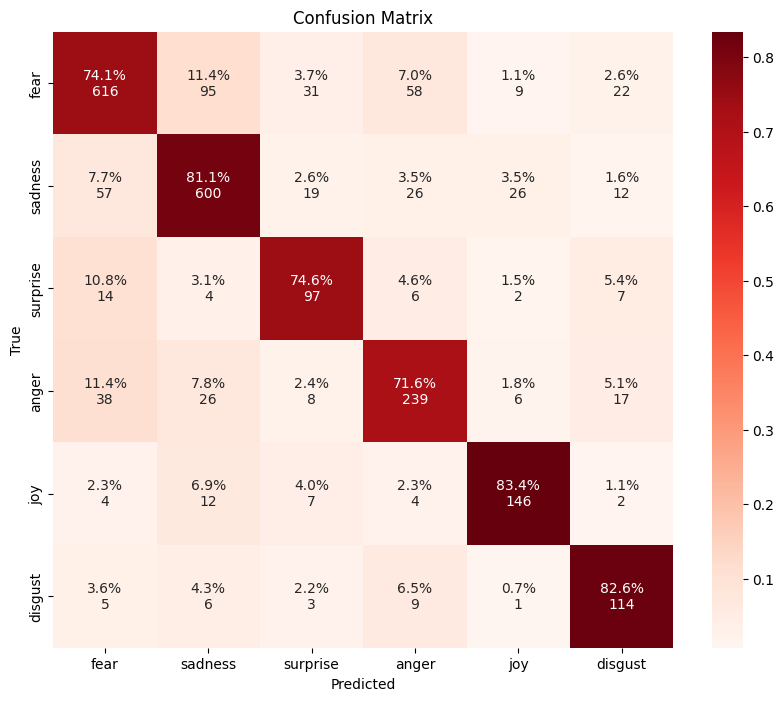

In [24]:
# Plot Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

labels = np.array([
    [f"{cm_normalized[i, j]*100:.1f}%\n{cm[i, j]}" for j in range(cm.shape[1])]
    for i in range(cm.shape[0])
])

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=labels, fmt="", cmap="Reds", xticklabels=emotions, yticklabels=emotions)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()